# ==========================================================
# Predictive Analytics for SME Financial Decision-Making
# Evaluated by: Monisola Beauty Ayankoya

# Project Description
  Small and Medium Enterprises (SMEs) play a critical role in economic growth, innovation, and employment generation which make up 99.9% of all firms. However, understanding the factors that influence financial decision-making within SMEs remains an important challenge for business leaders and analysts.

 This project applies predictive analytics techniques to examine and predict SME financial decision-making outcomes using organizational, financial, and managerial factors. By leveraging machine learning models and feature importance analysis, the study identifies key drivers of financial decision-making and demonstrates how predictive analytics can support data-driven financial optimization, risk management, and organizational resilience among SMEs.

# About the SME dataset
  This dataset contains financial decision-making data from SMEs, including establishment year, business type, sector, size, risk assessment practices, management decision-making factors, and financial analysis indicators, providing a foundation for predictive analytics and data-driven financial optimization.

# ==========================================================

# Data Overview

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.templates.default = "plotly_white"
sns.set()
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier,AdaBoostClassifier,BaggingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import roc_curve, auc


In [2]:
# Load the dataset
df_sme = 'sme_financial_decision.csv'
df_sme = pd.read_csv(df_sme)
df_sme.head()

,FQ1,Established_year,Type_SME,Sector,SME_Size,FL1,FL2,FL3,FL4,FR1,...,MDA3,MDA4,FDM1,FDM2,FDM3,FDM4,FA1,FA2,FA3,FA4
0,YES,3,3,1,1,3,3,3,5,2,...,5,4,3,5,5,5,3,3,3,5
1,YES,2,2,2,3,2,2,3,5,2,...,4,5,2,1,3,3,2,2,3,5
2,YES,3,2,1,3,3,3,5,5,2,...,5,4,3,3,3,3,3,3,5,5
3,YES,1,2,2,2,4,4,5,5,2,...,5,3,4,4,5,5,4,4,5,5
4,YES,2,2,3,4,3,3,3,5,4,...,4,4,3,3,3,3,3,3,3,5


In [3]:
# Load the dataset
df_sme = 'sme_financial_decision.csv'
df_sme = pd.read_csv(df_sme)
df_sme.tail()

,FQ1,Established_year,Type_SME,Sector,SME_Size,FL1,FL2,FL3,FL4,FR1,...,MDA3,MDA4,FDM1,FDM2,FDM3,FDM4,FA1,FA2,FA3,FA4
445,YES,2,1,2,3,3,3,5,3,2,...,5,4,3,3,3,3,4,4,5,4
446,YES,2,2,1,3,3,3,3,5,4,...,3,2,3,3,3,4,3,3,3,3
447,YES,2,4,2,3,3,3,3,3,4,...,4,3,3,3,3,3,4,4,5,4
448,YES,1,1,3,3,3,3,5,3,2,...,5,4,3,3,3,4,4,4,4,4
449,YES,3,2,4,2,4,4,4,4,3,...,5,4,4,4,4,3,4,4,4,4


In [4]:
df_sme.shape

(450, 29)

In [5]:
df_sme.columns

Index(['FQ1', 'Established_year', 'Type_SME', 'Sector', 'SME_Size', 'FL1',
       'FL2', 'FL3', 'FL4', 'FR1', 'FR2', 'FR3', 'FR4', 'RA1', 'RA2', 'RA3',
       'RA4', 'MDA1', 'MDA2', 'MDA3', 'MDA4', 'FDM1', 'FDM2', 'FDM3', 'FDM4',
       'FA1', 'FA2', 'FA3', 'FA4'],
      dtype='object')

# Exploratory Data Analysis

Descriptive Statistics

In [6]:
df_sme.describe()

,Established_year,Type_SME,Sector,SME_Size,FL1,FL2,FL3,FL4,FR1,FR2,...,MDA3,MDA4,FDM1,FDM2,FDM3,FDM4,FA1,FA2,FA3,FA4
count,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000,...,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000
mean,1.880000,2.557778,2.971111,2.764444,3.160000,3.188889,4.115556,3.442222,2.866667,2.133333,...,4.360000,3.433333,3.120000,3.326667,3.364444,3.337778,3.164444,3.213333,4.111111,3.517778
std,0.686361,0.988799,1.150796,1.083415,0.743914,0.782527,0.814664,0.959071,0.892932,1.120770,...,0.849053,0.767520,0.724254,0.638379,0.684267,0.729062,0.736922,0.794637,0.807046,1.005949
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000,1.000000,1.000000,1.000000,...,1.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000,1.000000
25%,1.000000,2.000000,2.000000,2.000000,3.000000,3.000000,3.000000,3.000000,2.000000,1.000000,...,4.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000
50%,2.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,3.000000,3.000000,2.000000,...,5.000000,4.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,3.000000
75%,2.000000,3.000000,4.000000,3.000000,4.000000,4.000000,5.000000,4.000000,4.000000,3.000000,...,5.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000
max,3.000000,4.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,4.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


This dataset contains 29 variables related to SME financial decision-making, including organizational characteristics (establishment year, SME type, sector, and size), financial literacy, financial resources, risk assessment, management decision attributes, financial decision-making practices, and financial analysis indicators. The dataset provides a foundation for analyzing factors that influence financial decision-making among SMEs.

# Correlation Analysis

To identify any strong relationship between the numeric features.

<AxesSubplot:>

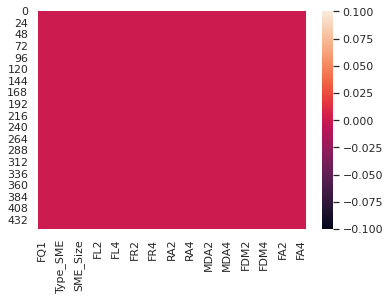

In [7]:
#Lets visualize it using heatmap
sns.heatmap(df_sme.isnull())

We can see clearly in the visualize that there is no missing data present.

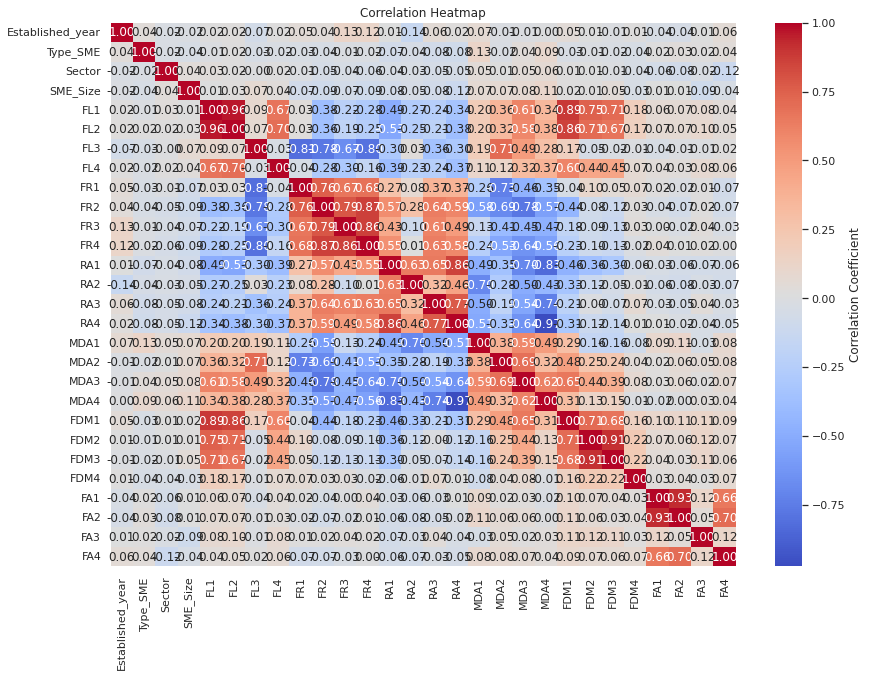

In [8]:
# Select only numeric columns
numeric_df = df_sme.select_dtypes(include=[np.number])

# Compute the correlation matrix
corr = numeric_df.corr()

# Plot the heatmap
plt.figure(figsize=(14, 10))

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    cbar_kws={'label': 'Correlation Coefficient'}
)

plt.title('Correlation Heatmap')
plt.show()

The correlation heatmap illustrates the relationships among the SME financial and managerial variables. Several positive correlations are observed among financial literacy, financial resources, risk assessment, management decision-making, financial analysis, and financial decision-making indicators, suggesting that these factors may collectively influence financial decision-making outcomes within SMEs.

# Data Visualization

Distribution of SME Types

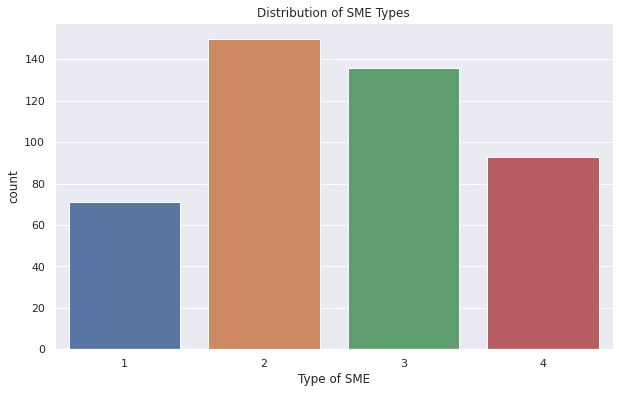

In [9]:
plt.figure(figsize = (10,6))
sns.countplot(x='Type_SME', data=df_sme, palette='deep')
plt.title('Distribution of SME Types')
plt.xlabel('Type of SME')
plt.ylabel('count')
plt.show()

# Risk Assessment and Decision Making
Exploring the relationship between risk assessment and decision-making attributes.

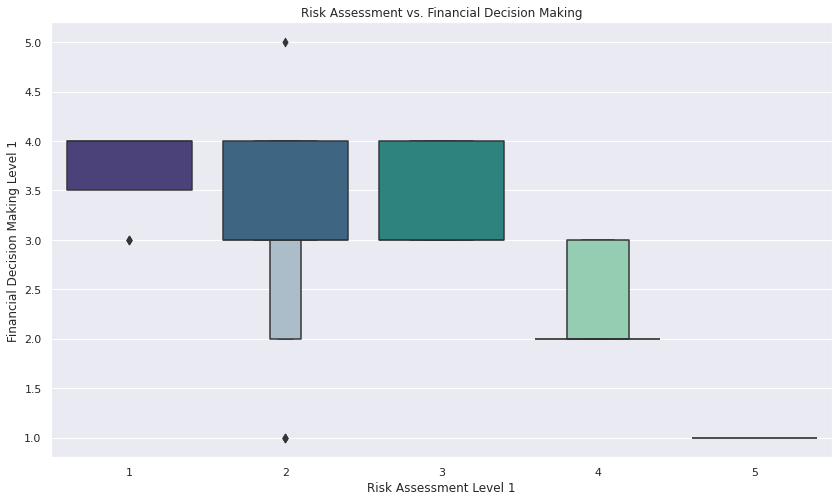

In [10]:
plt.figure(figsize = (14,8))
sns.boxenplot(x='RA1', y='FDM1', data=df_sme, palette='viridis')
plt.title('Risk Assessment vs. Financial Decision Making')
plt.xlabel('Risk Assessment Level 1')
plt.ylabel('Financial Decision Making Level 1')
plt.show()

# Predictive Modeling
To support data-driven financial optimization among SMEs, predictive analytics techniques were applied to forecast financial decision-making outcomes and identify the factors most strongly associated with effective financial decision-making.

# Model Training
Using logistic regression model

In [11]:
# Define features and target
X = numeric_df.drop(columns=['FDM1'])  # Assuming FDM1 is the target
y = numeric_df['FDM1']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

# Model Evaluation and Performance Assessment
The trained Logistic Regression model was evaluated using classification metrics including accuracy, precision, recall, F1-score, and the confusion matrix to assess its effectiveness in predicting SME financial decision-making outcomes.

In [12]:
# Predictions
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Model Accuracy: {accuracy:.2f}')

# Confusion Matrix
print("\nConfusion Matrix:")

print(confusion_matrix(y_test, y_pred))

# Classification Report
print("\nClassification Report:")

print(classification_report(y_test, y_pred))

Model Accuracy: 0.98

Confusion Matrix:
[[15  0  0  0]
 [ 1 51  0  0]
 [ 0  0 22  0]
 [ 0  0  1  0]]

Classification Report:
              precision    recall  f1-score   support

           2       0.94      1.00      0.97        15
           3       1.00      0.98      0.99        52
           4       0.96      1.00      0.98        22
           5       0.00      0.00      0.00         1

    accuracy                           0.98        90
   macro avg       0.72      0.75      0.73        90
weighted avg       0.97      0.98      0.97        90



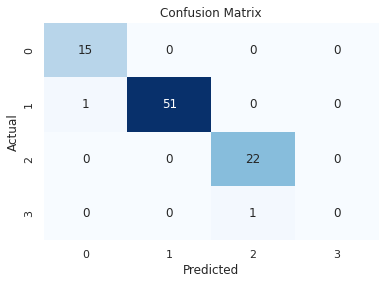

In [13]:
# Plot confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Random Forest Model

In [14]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [15]:
# Initialize model training
rf_model = RandomForestClassifier(
            n_estimators=100,
            random_state=42
)

# Train model
rf_model.fit(X_train, y_train)

# Predictions
rf_pred = rf_model.predict(X_test)

In [16]:
print("Random Forest Accuracy:",

accuracy_score(y_test, rf_pred))
print("\nClassification Report:")

print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.9888888888888889

Classification Report:
              precision    recall  f1-score   support

           2       1.00      1.00      1.00        15
           3       1.00      1.00      1.00        52
           4       0.96      1.00      0.98        22
           5       0.00      0.00      0.00         1

    accuracy                           0.99        90
   macro avg       0.74      0.75      0.74        90
weighted avg       0.98      0.99      0.98        90



# Feature Importance Analysis

Feature importance analysis revealed that Financial Literacy (FL1 and FL2) was the most influential predictor of SME financial decision-making, followed by financial decision-making indicators, management decision attributes, risk assessment factors, and financial resources. These findings suggest that financial knowledge and analytical capabilities play a critical role in supporting effective financial decision-making among SMEs.

In [17]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance.head(10)

,Feature,Importance
4,FL1,0.226133
5,FL2,0.174102
21,FDM3,0.113412
20,FDM2,0.111274
7,FL4,0.080440
16,MDA1,0.054558
14,RA3,0.030959
13,RA2,0.030587
17,MDA2,0.028810
9,FR2,0.026759


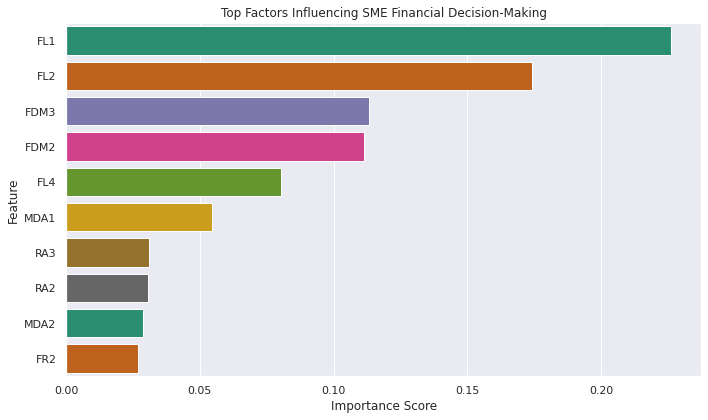

In [18]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    x='Importance',
    y='Feature',
    palette='Dark2'
)

plt.title('Top Factors Influencing SME Financial Decision-Making')
plt.xlabel('Importance Score')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()

The feature importance analysis indicates that Financial Literacy (FL1 and FL2) is the strongest predictor of SME financial decision-making outcomes, followed by financial decision-making indicators (FDM2 and FDM3), management decision attributes (MDA1 and MDA2), risk assessment factors (RA2 and RA3), and financial resources (FR2). This suggests that financial knowledge, analytical capabilities, and sound management practices play a significant role in supporting effective financial decision-making among SMEs.

# Gradient Boost Model

In [19]:
gb_model = GradientBoostingClassifier(
           n_estimators=100,
           learning_rate=0.1,
           random_state=42
)

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)

In [20]:
print("Gradient Boosting Accuracy:",
      accuracy_score(y_test, gb_pred))

print("\nClassification Report:")
print(classification_report(y_test, gb_pred))

Gradient Boosting Accuracy: 0.9777777777777777

Classification Report:
              precision    recall  f1-score   support

           2       1.00      1.00      1.00        15
           3       0.96      1.00      0.98        52
           4       1.00      0.95      0.98        22
           5       0.00      0.00      0.00         1

    accuracy                           0.98        90
   macro avg       0.74      0.74      0.74        90
weighted avg       0.97      0.98      0.97        90



In [21]:
results = pd.DataFrame({
    'Model': ['Logistic Regression',
              'Random Forest',
              'Gradient Boosting'],
    'Accuracy': [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, gb_pred)
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.977778
1,Random Forest,0.988889
2,Gradient Boosting,0.977778


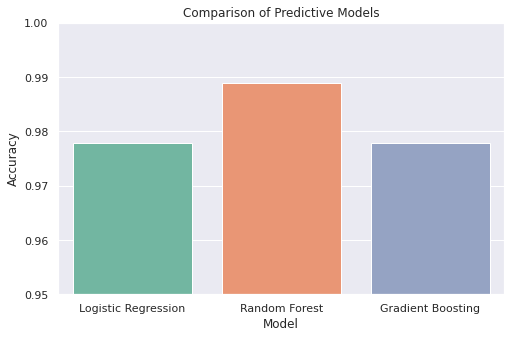

In [22]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x='Model',
    y='Accuracy',
    palette='Set2'
)

plt.title('Comparison of Predictive Models')
plt.ylim(0.95,1.00)

plt.show()

The comparison of predictive models shows that all three models achieved high prediction accuracy. Random Forest performed best with an accuracy of 98.89%, while Logistic Regression and Gradient Boosting each achieved 97.78%, indicating that all models were effective in predicting SME financial decision-making outcomes.

# Feature Engineering 

To improve predictive performance and uncover deeper insights into SME financial decision-making, feature engineering techniques were applied to transform and create more informative variables from the original dataset. These engineered features help capture meaningful relationships between organizational characteristics, financial analysis, risk assessment, and management decision-making factors.

In [23]:
df_sme['Risk_Assessment_Score'] = df_sme[
    ['RA1', 'RA2', 'RA3', 'RA4']
].mean(axis=1)

In [24]:
df_sme['Risk_Level'] = pd.cut(
    df_sme['Risk_Assessment_Score'],
    bins=[0, 2.5, 3.5, 5],
    labels=['Low', 'Medium', 'High']
)

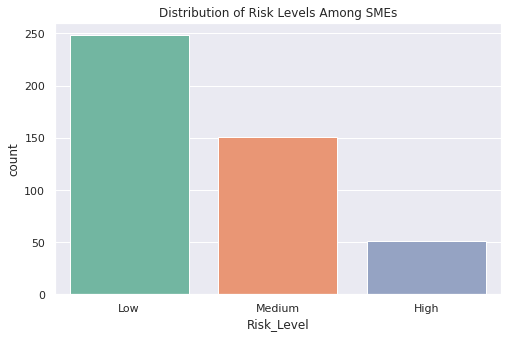

In [25]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Risk_Level',
    data=df_sme,
    palette='Set2'
)

plt.title('Distribution of Risk Levels Among SMEs')
plt.show()

# Cross-validation to ensure the model's robustness

In [26]:
# Logistic Regression
log_model = LogisticRegression(max_iter=1000)

log_cv = cross_val_score(
    log_model, X, y,
    cv=5,
    scoring='accuracy'
)

# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_cv = cross_val_score(
    rf_model, X, y,
    cv=5,
    scoring='accuracy'
)

# Gradient Boosting
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    random_state=42
)

gb_cv = cross_val_score(
    gb_model, X, y,
    cv=5,
    scoring='accuracy'
)

In [27]:
comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'Gradient Boosting'
    ],
    'Mean Accuracy': [
        log_cv.mean(),
        rf_cv.mean(),
        gb_cv.mean()
    ],
    'Std Dev': [
        log_cv.std(),
        rf_cv.std(),
        gb_cv.std()
    ]
})

comparison

,Model,Mean Accuracy,Std Dev
0,Logistic Regression,0.984444,0.020608
1,Random Forest,0.997778,0.004444
2,Gradient Boosting,0.997778,0.004444


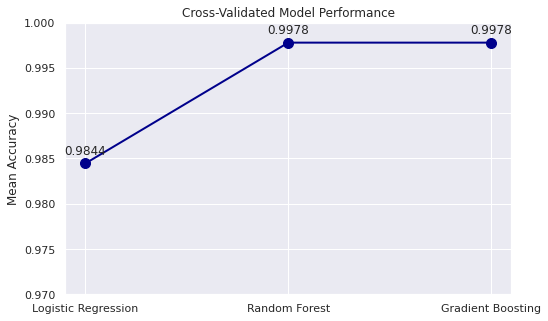

In [28]:
plt.figure(figsize=(8,5))

plt.plot(
    comparison['Model'],
    comparison['Mean Accuracy'],
    marker='o',
    linewidth=2,
    markersize=10,
    color='darkblue'
)

for i, v in enumerate(comparison['Mean Accuracy']):
    plt.text(i, v + 0.001, f'{v:.4f}', ha='center')

plt.ylim(0.97, 1.00)

plt.title('Cross-Validated Model Performance')
plt.ylabel('Mean Accuracy')

plt.grid(True)
plt.show()

# Business Insights and Recommendations

The predictive analytics results indicate that financial literacy is the most influential factor affecting SME financial decision-making outcomes. Financial literacy variables (FL1 and FL2) consistently emerged as the strongest predictors, suggesting that SMEs with greater financial knowledge are more likely to make effective financial decisions.

In addition, management decision attributes, risk assessment practices, and financial resources were identified as important contributors to financial decision-making performance. These findings suggest that SMEs benefit from combining financial knowledge with structured risk evaluation and sound managerial practices.

# Recommendations

- Strengthen Financial Literacy: SME owners and managers should invest in financial education and training programs to improve their understanding of budgeting, investment decisions, financial planning, and resource allocation.

- Enhance Risk Assessment Practices: SMEs should adopt formal risk assessment procedures to identify financial risks early and support more informed decision-making.

- Promote Data-Driven Decision-Making: Organizations should leverage financial data, analytics tools, and performance metrics to support strategic and operational financial decisions.

- Improve Financial Analysis Capabilities: Regular financial analysis and performance monitoring can help SMEs identify opportunities for growth, improve resource utilization, and enhance financial resilience.

- Support Managerial Decision Processes: Developing stronger management decision-making frameworks can improve organizational efficiency and contribute to better financial outcomes.

Overall, the findings demonstrate that predictive analytics can provide valuable insights into SME financial behavior and support data-driven financial optimization, improved decision-making, and long-term organizational resilience.

# Summary and Conclusion

This project applied predictive analytics and machine learning techniques to examine the factors influencing financial decision-making among Small and Medium Enterprises (SMEs). Through descriptive statistics, correlation analysis, predictive modeling, cross-validation, and feature importance analysis, the study identified key drivers of SME financial decision-making and demonstrated the value of data-driven approaches in supporting organizational performance.

Three machine learning models were evaluated: Logistic Regression, Random Forest, and Gradient Boosting. The results showed strong predictive performance across all models, with Random Forest achieving the highest accuracy (98.89%), followed by Logistic Regression and Gradient Boosting (97.78%). Cross-validation further confirmed the robustness and reliability of the predictive models.

Feature importance analysis revealed that financial literacy, management decision attributes, risk assessment practices, financial resources, and financial analysis indicators were among the most influential factors affecting financial decision-making outcomes. These findings highlight the critical role of analytical capabilities and informed decision-making in supporting SME financial performance and resilience.

Overall, this study demonstrates how predictive analytics can be leveraged to support data-driven financial optimization, improve decision-making quality, strengthen risk management practices, and enhance organizational resilience among SMEs. The findings contribute to a broader understanding of how analytical tools and machine learning techniques can assist businesses in making more informed financial decisions, improving operational effectiveness, and supporting sustainable growth.

# The End